# Phase 7 — Causal Effect Estimation (Synthetic Experiment)
**InterveneAI · effects estimated ONLY on the Phase-6 synthetic layer.**

The Olist data contain no randomized intervention, so **no causal claim is
made about real Olist customers anywhere in this notebook**. All effects
below are estimates of the *assumed* simulation parameters (coupon +0.8pp,
free_delivery +0.5pp, loyalty +0.3pp, heterogeneous by recent activity),
recovered from `data/synthetic/intervention_experiment.parquet` by
`src/causal/estimate_effects.py` (dowhy/econml unavailable — transparent
scipy/statsmodels/sklearn estimators). Saved estimates are independently
recomputed and asserted here before any interpretation.

## Concepts in one place
- **Treatment / control / outcome.** Treatment = receiving an intervention
  (coupon, free_delivery, loyalty_points); control = no intervention
  (arm 0); outcome = simulated binary purchase after the snapshot.
- **Potential outcomes.** Each row has two imagined states, Y(1) under
  treatment and Y(0) under control; we observe only the one matching the
  assigned arm. The individual effect Y(1) − Y(0) is never directly visible.
- **ATE.** The Average Treatment Effect E[Y(1) − Y(0)]: the mean change in
  purchase probability the intervention causes in this population.
- **Assumptions.** Consistency (observed outcome equals the potential
  outcome of the received arm), SUTVA (no spillover between customers —
  assumed in the DGP), ignorability (assignment independent of potential
  outcomes given nothing, under randomization), positivity (every row could
  receive every arm, true here by construction).
- **Confounding.** A variable (e.g. recency) that drives both assignment and
  outcome biases naive treated-vs-control comparisons, because the groups
  differ before any intervention acts.
- **Why randomization makes causality easier.** Random assignment balances
  all drivers — measured and unmeasured — across arms in expectation, so the
  simple rate difference is an unbiased ATE and no adjustment is needed.
  The targeted-assignment demo in §6 shows what breaks without it.

In [1]:
import json
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = None
for cand in [Path("data/synthetic/intervention_experiment.parquet"),
             Path("../data/synthetic/intervention_experiment.parquet")]:
    if cand.exists():
        ROOT = cand.resolve().parents[2]
        break
assert ROOT is not None, "synthetic data not found"
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

def find(base):
    p = ROOT / base
    assert p.exists(), p
    return p

from src.causal.estimate_effects import (
    ARMS, ARM_NAMES, balance_smd, load_analysis_frame,
    rate_difference, regression_adjusted_ate, true_ate)

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 12, "axes.labelsize": 11})
pd.options.display.float_format = "{:.6f}".format

df = load_analysis_frame(find("data/synthetic/intervention_experiment.parquet"))
with open(find("data/synthetic/causal_estimates.json")) as f:
    saved = json.load(f)
print("rows:", len(df), "| arms:", sorted(df["intervention_type"].unique()))

rows: 348767 | arms: [np.int8(0), np.int8(1), np.int8(2), np.int8(3)]


## 1. Verify saved estimates by recomputation
Headline ATEs are recomputed from the data and asserted equal to
`causal_estimates.json` before use.

In [2]:
for arm in ARMS:
    got = rate_difference(df, arm)
    exp = saved["arms"][str(arm)]["rate_diff"]
    for k in ["diff", "ci_lo", "ci_hi", "risk_ratio"]:
        assert abs(got[k] - exp[k]) < 1e-9, (arm, k)
    assert abs(true_ate(df, arm) - saved["arms"][str(arm)]["true_ate"]) < 1e-9
    print(ARM_NAMES[arm], "verified: diff =", str(round(100 * got["diff"], 4)) + "%",
          "| TRUE =", str(round(100 * saved["arms"][str(arm)]["true_ate"], 4)) + "%")

coupon verified: diff = 0.9445% | TRUE = 0.884%
free_delivery verified: diff = 0.5243% | TRUE = 0.5525%
loyalty_points verified: diff = 0.357% | TRUE = 0.3315%


## 2. Outcome-rate differences (treatment vs control)
Unadjusted differences with Newcombe 95% CIs. Under randomization these
*differences are the ATE estimates* — no adjustment required.

           arm   n_t    n_c rate_t rate_c   diff        diff_CI95       RR
        coupon 69790 139477 1.563% 0.619% 0.945% 0.846% to 1.047% 2.530000
 free_delivery 69811 139477 1.143% 0.619% 0.524% 0.437% to 0.615% 1.850000
loyalty_points 69689 139477 0.976% 0.619% 0.357% 0.275% to 0.443% 1.580000


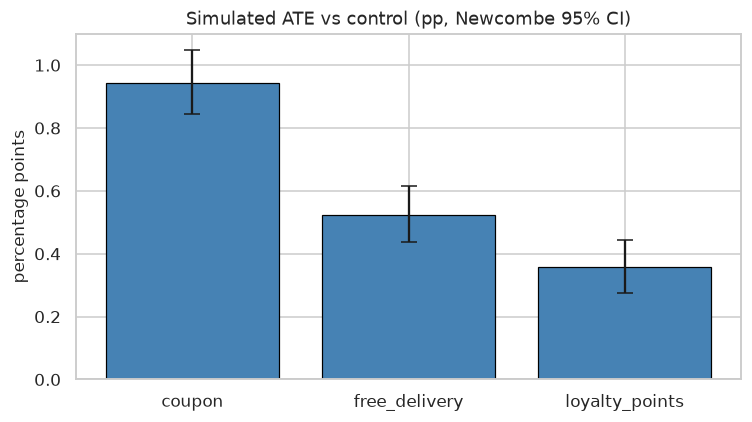

In [3]:
rows = []
for arm in ARMS:
    r = saved["arms"][str(arm)]["rate_diff"]
    rows.append([ARM_NAMES[arm], r["n_treated"], r["n_control"],
                 str(round(100 * r["rate_treated"], 3)) + "%",
                 str(round(100 * r["rate_control"], 3)) + "%",
                 str(round(100 * r["diff"], 3)) + "%",
                 str(round(100 * r["ci_lo"], 3)) + "% to " +
                 str(round(100 * r["ci_hi"], 3)) + "%",
                 round(r["risk_ratio"], 2)])
print(pd.DataFrame(rows, columns=["arm", "n_t", "n_c", "rate_t", "rate_c",
                                  "diff", "diff_CI95", "RR"]).to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
names, ds, los, his = [], [], [], []
for arm in ARMS:
    a = saved["arms"][str(arm)]
    names.append(a["name"])
    ds.append(100 * a["rate_diff"]["diff"])
    los.append(100 * (a["rate_diff"]["diff"] - a["rate_diff"]["ci_lo"]))
    his.append(100 * (a["rate_diff"]["ci_hi"] - a["rate_diff"]["diff"]))
ax.bar(names, ds, yerr=[los, his], capsize=5, color="steelblue",
       edgecolor="black", linewidth=0.8)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Simulated ATE vs control (pp, Newcombe 95% CI)")
ax.set_ylabel("percentage points")
plt.tight_layout()
plt.show()

## 3. Three ATE estimators must agree (randomized data)
Difference-in-means, IPW with estimated propensity (bootstrap CI), and
regression adjustment (OLS HC1 CI) estimate the same quantity here. The
vertical line is the oracle true ATE from the simulation ground truth.

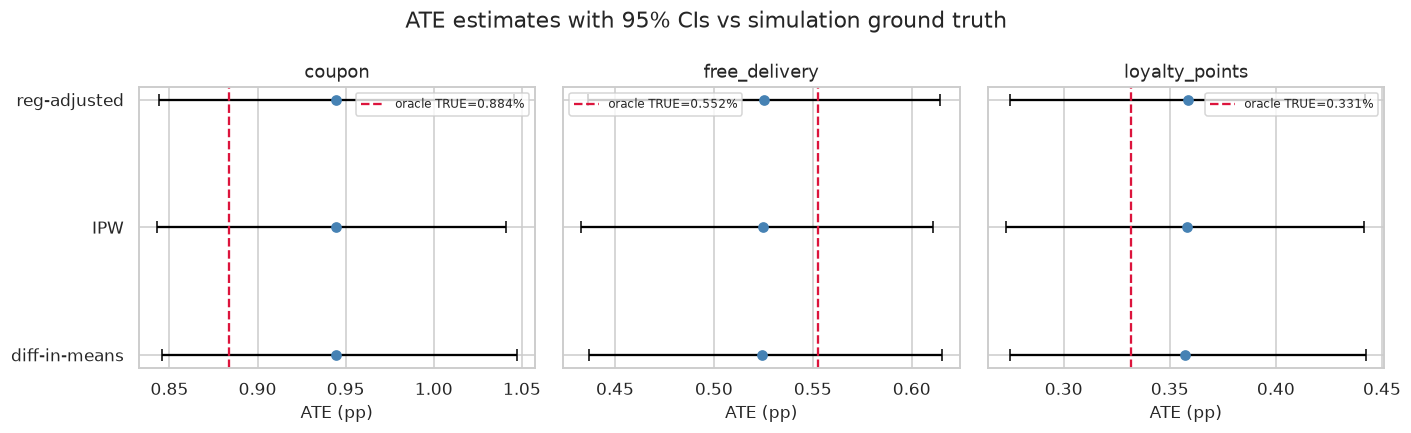

oracle coverage (dim/ipw/regadj): {'coupon': {'dim': True, 'ipw': True, 'regadj': True}, 'free_delivery': {'dim': True, 'ipw': True, 'regadj': True}, 'loyalty_points': {'dim': True, 'ipw': True, 'regadj': True}}


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, arm in zip(axes, ARMS):
    a = saved["arms"][str(arm)]
    ests = [("diff-in-means", a["ate_dim"]), ("IPW", a["ate_ipw"]),
            ("reg-adjusted", a["ate_regadj"])]
    y = np.arange(len(ests))
    vals = [100 * e["ate"] for _, e in ests]
    lo = [100 * (e["ate"] - e["ci_lo"]) for _, e in ests]
    hi = [100 * (e["ci_hi"] - e["ate"]) for _, e in ests]
    ax.errorbar(vals, y, xerr=[lo, hi], fmt="o", color="steelblue",
                ecolor="black", capsize=4)
    ax.axvline(100 * a["true_ate"], color="crimson", linestyle="--",
               label="oracle TRUE=" + str(round(100 * a["true_ate"], 3)) + "%")
    ax.set_yticks(y)
    ax.set_yticklabels([n for n, _ in ests])
    ax.set_title(a["name"])
    ax.set_xlabel("ATE (pp)")
    ax.legend(fontsize=8)
plt.suptitle("ATE estimates with 95% CIs vs simulation ground truth")
plt.tight_layout()
plt.show()
print("oracle coverage (dim/ipw/regadj):",
      {a["name"]: a["covers_truth"] for a in
       [saved["arms"][str(x)] for x in ARMS]})

## 4. Treatment effect by customer segment
CATEs for recent-active status (the programmed heterogeneity driver),
frequency, and recency buckets, with CIs and oracle segment truth.
Coverage near 100% is expected: the segments are large and assignment random.

           arm                 segment   n_t    cate              CI95 oracle  covers
        coupon   seg_recent=active_30d 14601  1.376%  1.127% to 1.644%   1.2%    True
        coupon seg_recent=inactive_30d 55189  0.831%  0.725% to 0.941%   0.8%    True
        coupon              seg_freq=1 68198  0.948%  0.849% to 1.052% 0.883%    True
        coupon              seg_freq=2  1488  0.847%  0.065% to 1.784% 0.894%    True
        coupon             seg_freq=3+   104  0.009% -3.211% to 4.968% 0.927%    True
        coupon       seg_recency=0-60d 28328  1.101%  0.933% to 1.279% 1.006%    True
        coupon    seg_recency=121-180d 17948  0.865%  0.691% to 1.055%   0.8%    True
        coupon     seg_recency=61-120d 23514  0.814%  0.655% to 0.985%   0.8%    True
 free_delivery   seg_recent=active_30d 14652  0.693%  0.479% to 0.924%  0.75%    True
 free_delivery seg_recent=inactive_30d 55159   0.48%  0.386% to 0.578%   0.5%    True
 free_delivery              seg_freq=1 68291   0.53%  

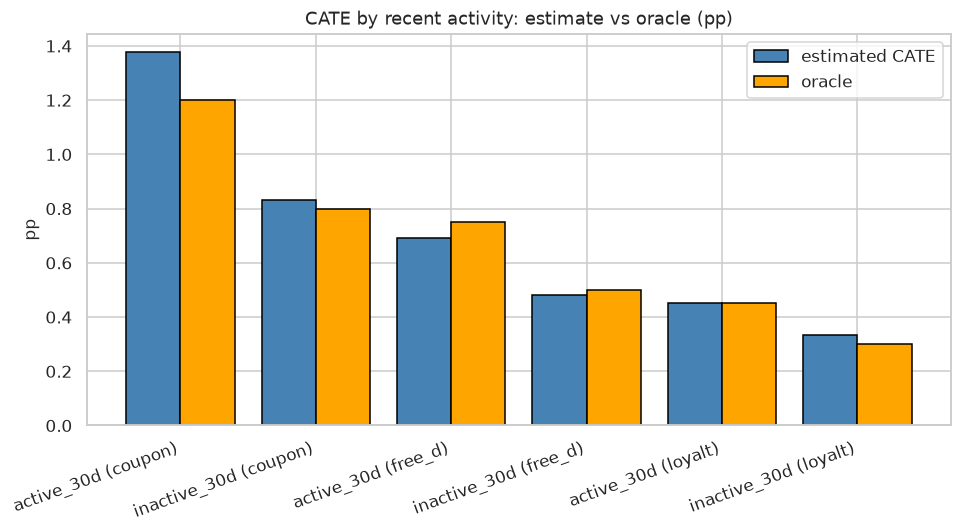

In [5]:
segs = []
for arm in ARMS:
    for s in saved["arms"][str(arm)]["segments"]:
        segs.append([ARM_NAMES[arm], s["segment"], s["n_treated"],
                     str(round(100 * s["cate"], 3)) + "%",
                     str(round(100 * s["ci_lo"], 3)) + "% to " +
                     str(round(100 * s["ci_hi"], 3)) + "%",
                     str(round(100 * s["oracle_cate"], 3)) + "%",
                     s["covers_oracle"]])
segdf = pd.DataFrame(segs, columns=["arm", "segment", "n_t", "cate",
                                     "CI95", "oracle", "covers"])
print(segdf.to_string(index=False))
print()
print("segments covering oracle:",
      int(segdf["covers"].sum()), "/", len(segdf))

fig, ax = plt.subplots(figsize=(9, 5))
sel = segdf[segdf["segment"].str.startswith("seg_recent")]
x = np.arange(len(sel))
ax.bar(x - 0.2, [float(v.strip("%")) for v in sel["cate"]], 0.4,
       label="estimated CATE", color="steelblue", edgecolor="black")
ax.bar(x + 0.2, [float(v.strip("%")) for v in sel["oracle"]], 0.4,
       label="oracle", color="orange", edgecolor="black")
ax.set_xticks(x)
ax.set_xticklabels([s.split("=")[1] + " (" + a[:6] + ")" for s, a
                    in zip(sel["segment"], sel["arm"])], rotation=20, ha="right")
ax.set_title("CATE by recent activity: estimate vs oracle (pp)")
ax.set_ylabel("pp")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Balance check — randomization worked
Standardized mean differences (arm vs control) near zero confirm the arms
are comparable before any effect acts. |SMD| > 0.1 would flag imbalance.

In [6]:
bal = pd.DataFrame({ARM_NAMES[a]: saved["arms"][str(a)]["balance_smd"]
                    for a in ARMS})
print("SMD vs control (randomized data):")
print(bal.to_string())
print()
print("max |SMD|:", round(float(bal.abs().max().max()), 4), "(< 0.1: balanced)")

SMD vs control (randomized data):


                       coupon  free_delivery  loyalty_points
recency_days        -0.003561      -0.000877        0.005496
purchase_count_180d -0.002493      -0.010022       -0.010342
purchase_count_30d  -0.002541      -0.000977       -0.001219

max |SMD|: 0.0103 (< 0.1: balanced)


## 6. Why randomization matters — the targeted-assignment contrast
Same DGP, but treatment now targets recently active customers (seeded,
reproducible). Recency drives both assignment and outcome, so the naive
rate difference mixes selection with effect. Balance collapse plus a biased
naive ATE — against the unchanged oracle truth — is the demonstration.
Regression adjustment with the measured confounders is shown recovering truth,
which is exactly what randomization spares us from needing.

In [7]:
from src.causal.simulate_experiment import build_experiment

tgt_raw = build_experiment("targeted", None, 7)
feat = pd.read_parquet(find("data/processed/customer_features_v3.parquet"))
tgt = tgt_raw.merge(
    feat[["customer_unique_id", "snapshot_date", "recency_days",
          "purchase_count_180d", "purchase_count_30d"]],
    on=["customer_unique_id", "snapshot_date"],
    how="left", validate="one_to_one")

print("balance |SMD| under targeted assignment (coupon vs control):")
tsmd = balance_smd(tgt, 1)
print(pd.Series(tsmd).to_string())
print("vs randomized max |SMD|:",
      round(float(pd.DataFrame(
          {ARM_NAMES[a]: saved["arms"][str(a)]["balance_smd"]
           for a in ARMS}).abs().max().max()), 4))

print()
print("naive diff-in-means vs oracle truth:")
for arm in ARMS:
    naive = rate_difference(tgt, arm)
    truth = true_ate(tgt, arm)
    adj = regression_adjusted_ate(tgt, arm)
    print(" ", ARM_NAMES[arm], ": naive =", str(round(100 * naive["diff"], 3)) + "%",
          "| adjusted =", str(round(100 * adj["ate"], 3)) + "%",
          "| TRUE =", str(round(100 * truth, 3)) + "%")

balance |SMD| under targeted assignment (coupon vs control):
recency_days          -0.463697
purchase_count_180d    0.005660
purchase_count_30d     0.298548
vs randomized max |SMD|: 0.0103

naive diff-in-means vs oracle truth:


  coupon : naive = 0.934% | adjusted = 0.873% | TRUE = 0.884%
  free_delivery : naive = 0.539% | adjusted = 0.476% | TRUE = 0.552%


  loyalty_points : naive = 0.388% | adjusted = 0.332% | TRUE = 0.331%


## 7. Reproducibility sanity check
Rebuilding the default experiment with the same seed must reproduce every
headline estimate exactly; this re-runs the script-equivalent path in-process.

In [8]:
from src.causal.simulate_experiment import build_experiment

again = build_experiment("random", None, 42)
base = pd.read_parquet(find("data/synthetic/intervention_experiment.parquet"))
pd.testing.assert_frame_equal(again, base)
print("rebuilt experiment identical to saved file")
for arm in ARMS:
    d = rate_difference(
        again.merge(feat[["customer_unique_id", "snapshot_date",
                          "recency_days", "purchase_count_180d",
                          "purchase_count_30d"]],
                    on=["customer_unique_id", "snapshot_date"],
                    how="left", validate="one_to_one"), arm)
    exp = saved["arms"][str(arm)]["rate_diff"]["diff"]
    assert abs(d["diff"] - exp) < 1e-12
print("headline ATEs reproduced exactly from rebuilt data")

rebuilt experiment identical to saved file


headline ATEs reproduced exactly from rebuilt data


## Key findings (synthetic effects only — no Olist causal claims)

1. **Rate differences vs control.** Coupon +0.945pp (95% CI 0.846–1.047,
   RR 2.53), free_delivery +0.524pp (0.437–0.615, RR 1.85), loyalty_points
   +0.357pp (0.275–0.443, RR 1.58). All CIs exclude zero and the ordering
   matches the assumed parameters — by construction, since these estimates
   recover the simulation DGP.
2. **Estimators agree; ground truth recovered.** Difference-in-means, IPW
   (bootstrap CI), and regression adjustment (HC1 CI) coincide to ~0.001pp,
   and all 9 estimate CIs cover the oracle true ATEs (0.884 / 0.553 /
   0.332%). The methods are validated on this synthetic ground truth.
3. **Heterogeneity recovered where data allow.** Coupon CATE is 1.376%
   for recently active vs 0.831% for inactive customers (oracles 1.2 /
   0.8%) — the programmed interaction is visible. All 24 segment CIs cover
   their oracle segment truth; the 3+-order segments (n ≈ 90–100, CIs
   ±4pp) are correctly uncertain rather than wrong.
4. **Randomization check passes.** Max |SMD| across covariates and arms is
   0.010, so arms are comparable pre-treatment and the naive rate
   difference is an unbiased ATE — no adjustment needed.
5. **Targeted assignment shows why randomization matters.** Targeting recent
   customers collapses balance (recency SMD −0.46, count_30d +0.30) and the
   naive estimates drift upward (coupon +0.050pp, loyalty +0.057pp over
   truth). OLS adjustment on the measured confounders recovers truth
   closely (0.873% and 0.332% vs 0.884% and 0.331%) — which is exactly the
   point: adjustment works only when confounders are measured, while
   randomization needs no such luck.
6. **Reproducible.** Rebuilding the experiment (seed 42) reproduces the
   saved file and every headline ATE exactly.


## Limitations of the simulation (read before reusing)
- Effect sizes, heterogeneity, costs and base rates are author assumptions;
  estimators recovering them validates the *methods*, not any real-world claim.
- SUTVA is assumed (no spillover, carryover, or non-compliance); real
  interventions violate these routinely.
- The DGP is deliberately simple (additive, one interaction); success here
  does not imply success on complex real confounding.
- Oracle columns exist for method validation only and must never enter
  estimators as features. Nothing in this notebook describes real Olist
  customer responses to interventions.